In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def kde(X,K=30):
    n = len(X)
    X = np.array(X)
    h_u = 1.84 * X.std() * n ** (-0.2) # Compute bandwidth
    print(f'Plug-in Bandwidth Estimated is: {h_u:2f}')
    x_grid = np.linspace( X.min()-2*h_u, X.max()+2*h_u, K) # Create a grid to plot
    I = np.abs( x_grid[:,None] - X[None,:]) < h_u # Broadcast the indicator
    f_hat = np.sum(I,axis=1)/(2 * n * h_u) # Compute kde
    plt.step(x_grid,f_hat,where='mid')
    plt.fill_between(x_grid,f_hat,step='mid')
    plt.show()
    return x_grid, f_hat

In [3]:
def kde_g(X, h = 0.0, plot = True):
    X = np.array(X)
    gauss = lambda z: np.exp( -z**2 / 2) / np.sqrt(2 * np.pi) # Gaussian kernel
    n = len(X)
    if h == 0.0:
        h = 1.06 * X.std() * n ** (-0.2) # Compute bandwidth
        print(f'Plug-in Bandwidth Estimated is: {h:2f}')
    x_grid = np.linspace( X.min()-2*h, X.max()+2*h, 100) # Create a grid to plot
    K = gauss( (x_grid[:,None] - X[None,:])/h)/h # Broadcast the indicator
    f_hat = K.mean(axis=1)
    if plot:
        plt.plot(x_grid,f_hat)
        plt.title('KDE Estimator')
        plt.show()
    return x_grid, f_hat, h

# Problem 1

### Part A

<Axes: ylabel='Proportion'>

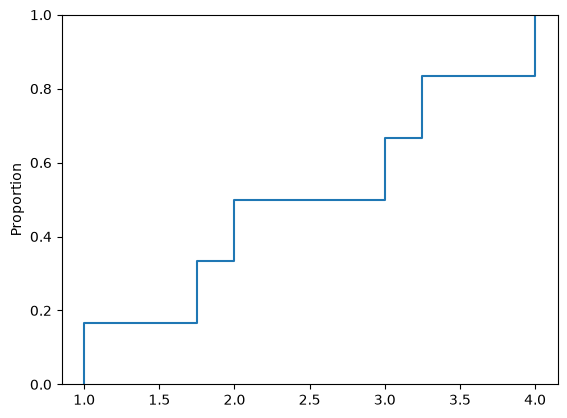

In [4]:
X = np.array([1, 1.75, 2, 3, 3.25, 4])
sns.ecdfplot(x=X)

### Part B

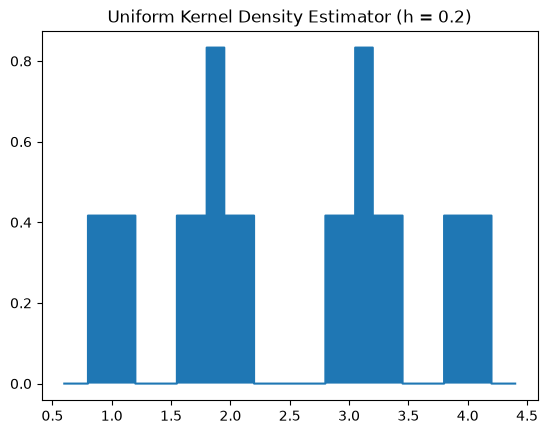

In [5]:
h = 0.2
xs = np.linspace(X.min() - 2*h, X.max() + 2*h, 1000)
f_hat = np.sum(np.abs(xs[:, None] - X[None, :]) < h, axis=1) / (2 * len(X) * h)
plt.step(xs, f_hat, where="mid")
plt.fill_between(xs, f_hat, step="mid")
plt.title("Uniform Kernel Density Estimator (h = 0.2)")
plt.show()

### Part C

In [6]:
n = len(X)
mean = X.mean()
dev = X - mean
sq_dev = dev ** 2
ss = sq_dev.sum()
var = ss / n
sd = var ** 0.5
h = 1.84 * sd * n ** (-0.2)
print('h =', h)

h = 1.2991670409500977


### Part D

Plug-in Bandwidth Estimated is: 1.299167


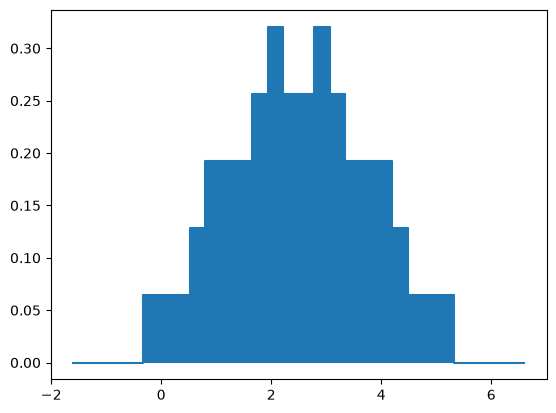

In [7]:
x_grid, f_hat = kde(X)

### Part E

Both charts use the same estimator on the same data and share the same blocky shape, but they differ in the bandwidth. The chart from part b looks overfit to the data, with gaps between the blocks, while part d looks much more like a natural density curve.

# Problem 2

### Part A

In [8]:
X2 = np.array([-1, -0.5, 0, 0.5, 1])
h = 0.6
in_window = np.abs(X2 - 0) < h
f_hat_0 = in_window.sum() / (2 * len(X2) * h)
print('f_hat(0) =', f_hat_0)

f_hat(0) = 0.5


### Part B

f_hat(0) = (1 / (2 * n * h)) * sum over i of 1{|Xi| < h}

E[f_hat(0)] = (1 / (2 * n * h)) * n * E[1{|X| < h}]

E[1{|X| < h}] = P(|X| < h)

E[f_hat(0)] = P(|X| < h) / (2 * h)

E[f_hat(0)] = (P(X < h) - P(X < -h)) / (2 * h)

E[f_hat(0)] = (P(X < 0.6) - P(X < -0.6)) / 1.2

In [9]:
from scipy.stats import norm
E_f_hat_0 = (norm.cdf(0.6) - norm.cdf(-0.6)) / (2 * 0.6)
print('E[f_hat(0)] =', E_f_hat_0)

E[f_hat(0)] = 0.3762448037498774


### Part C

In [10]:
f_0 = norm.pdf(0)
print('f(0) =', f_0)

f(0) = 0.3989422804014327


### Part D

They are not equal. E[f_hat(0)] = 0.3762 while the true density is f(0) = 0.3989, so the estimate is biased downward at this point by about 0.023. This comes from the smoothing. Each observation contributes a flat block of width 2h instead of keeping all of its mass at a single point, which flattens the peak of the estimate below the true density. Since n never entered E[f_hat(0)], more data does not remove this bias at a fixed bandwidth. And this is only the value at one point, so a full bias statement would require comparing E[f_hat] to f for all x.

### Part E

In [11]:
E_f_hat_0_small = (norm.cdf(0.1) - norm.cdf(-0.1)) / (2 * 0.1)
print('E[f_hat(0)] =', E_f_hat_0_small)
print('gap =', f_0 - E_f_hat_0_small)

E[f_hat(0)] = 0.3982783727702899
gap = 0.0006639076311428238


The gap shrinks sharply, from about 0.023 at h = 0.6 to about 0.0007 at h = 0.1. This fits the picture from part d, since the bias comes from averaging the density over the window, so a narrower window distorts the peak less. As h shrinks toward zero, the bias goes to zero as well.

### Part F

It can be consistent, but only if the bandwidth shrinks as the sample grows. Consistency means the estimate converges to the true density as n grows, which requires both the bias and the variance to vanish. The bias depends on h alone, since n dropped out of E[f_hat(0)] in part b, so it only goes away if h goes to zero. The variance depends on how many observations fall near each point, so it vanishes only when the number of points in the window keeps growing, meaning n * h grows without bound. A fixed bandwidth is therefore not consistent, since the estimate would converge to a smoothed version of the density rather than the density itself. With h shrinking as n grows while n * h still grows, for example at the Silverman rate proportional to n**(-0.2), both bias and variance collapse and the estimator is consistent.

### Part G

The main tension is the balance between bias and variance, which here shows up as overfitting versus underfitting. If h is too small the estimate overfits, leaving it spiky and noisy because it tracks the sample too closely, which can make sampling noise look like real structure. If h is too large it underfits, smoothing too aggressively and flattening the density's real features. So the bandwidth should be small enough to preserve real bumps and modes but large enough to average out the noise. Larger samples support smaller bandwidths, which is why bandwidth formulas scale h down with n at the n**(-0.2) rate, and h must also scale with the spread of the data, since they multiply by the standard deviation. The kernel choice interacts too, which is why the uniform kernel uses the 1.84 constant and the Gaussian uses 1.06.

# Problem 3

### Part A

In [12]:
X3 = np.array([5, 7, 7, 8, 10])
h = 1.5
xs3 = np.array([6.0, 6.5, 7.0, 8.0, 8.5])
f_hat_u = np.sum(np.abs(xs3[:, None] - X3[None, :]) < h, axis=1) / (2 * len(X3) * h)
for x, v in zip(xs3, f_hat_u):
    print(f'f_hat({x}) = {v:.4f}')

f_hat(6.0) = 0.2000
f_hat(6.5) = 0.1333
f_hat(7.0) = 0.2000
f_hat(8.0) = 0.2000
f_hat(8.5) = 0.0667


### Part B

In [13]:
f_hat_g = np.sum(np.exp(-((xs3[:, None] - X3[None, :]) / h) ** 2 / 2) / np.sqrt(2 * np.pi), axis=1) / (len(X3) * h)
for x, v in zip(xs3, f_hat_g):
    print(f'f_hat({x}) = {v:.4f}')

f_hat(6.0) = 0.1512
f_hat(6.5) = 0.1687
f_hat(7.0) = 0.1780
f_hat(8.0) = 0.1674
f_hat(8.5) = 0.1506


### Part C

The biggest jump in part a is the drop between x = 8.0 and x = 8.5, from 0.2000 down to 0.0667. The uniform kernel makes f_hat piecewise constant, since each observation contributes a flat block of width 2h and the estimate only changes when a block edge is crossed, moving by exactly 1/(2nh) for each point that enters or leaves. At x = 8.5 both observations at 7 leave the window at once, because their distance is exactly h and the strict inequality excludes them, while the 10 has not entered yet, so the count falls from 3 to 1 and the value drops by two blocks, 2/(2nh) = 0.1333. The Gaussian kernel has no edges to cross. Each observation contributes a smooth bell that keeps decaying with distance, so no contribution ever switches on or off, and the estimate can only move gradually. That is why the same five points give abrupt steps under the uniform kernel but a smooth curve under the Gaussian.

### Part D

Mostly because of smoothness. The Gaussian kernel produces smooth, gradual estimates, while the uniform kernel is blocky by nature and its estimate jumps abruptly at the edges of each block, as parts a and b show. That makes the Gaussian kernel better suited to continuous data, since it blends neighboring observations together, and the uniform kernel a more faithful representation of discrete data, since its blocky steps behave like histogram bins. The uniform kernel is also simpler to work with, since computing it just means counting points in a window and dividing.

# Problem 4

### Part A

Plug-in Bandwidth Estimated is: 4.005037


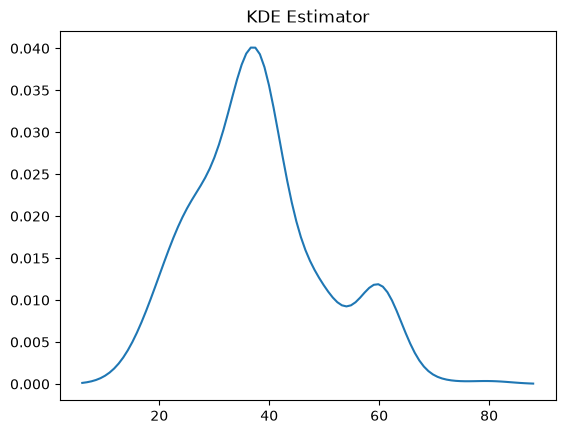

In [14]:
df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
x_grid, f_hat, h = kde_g(df['ejection_fraction'])

### Part B

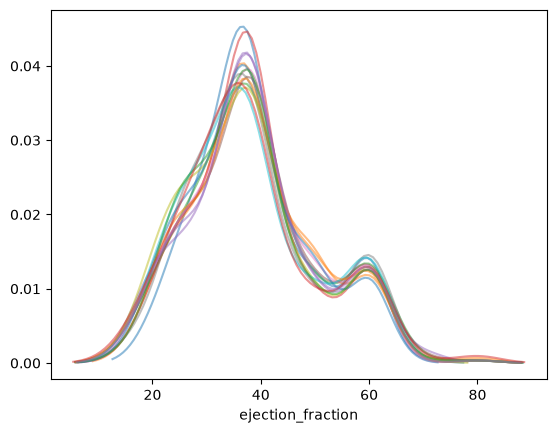

In [15]:
for i in range(15):
    sample = df['ejection_fraction'].sample(frac=1.0, replace=True, random_state=i)
    h_i = 1.06 * np.std(sample) * len(sample) ** (-0.2)
    xg, fg, hg = kde_g(sample, h=h_i, plot=False)
    plt.plot(xg, fg, alpha=0.5)
plt.xlabel('ejection_fraction')
plt.show()

### Part C

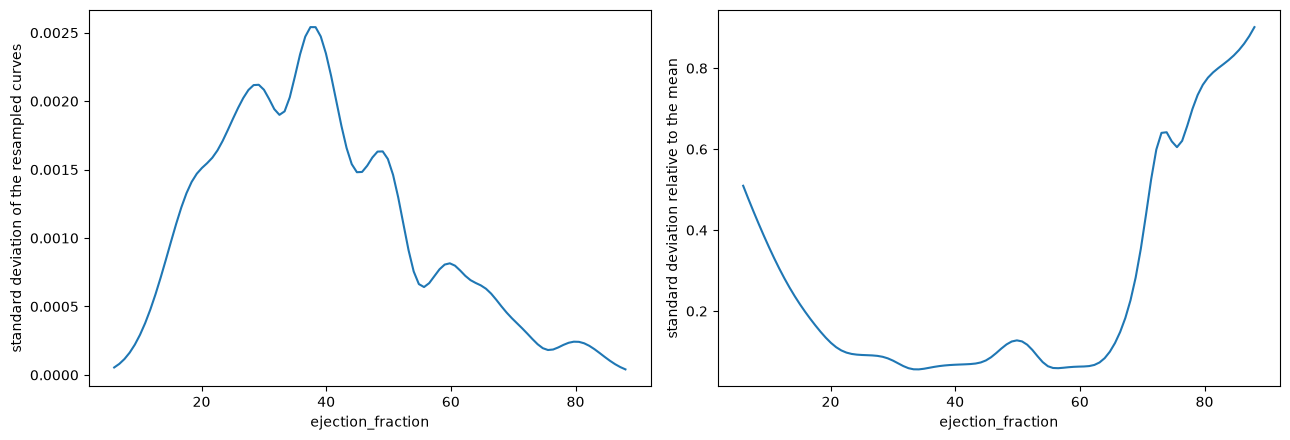

In [17]:
curves = []
for i in range(15):
    sample = df['ejection_fraction'].sample(frac=1.0, replace=True, random_state=i)
    h_i = 1.06 * np.std(sample) * len(sample) ** (-0.2)
    s = sample.to_numpy()
    fg = np.mean(np.exp(-((x_grid[:, None] - s) / h_i) ** 2 / 2) / np.sqrt(2 * np.pi) / h_i, axis=1)
    curves.append(fg)
variation = np.std(curves, axis=0)
rel_variation = variation / np.mean(curves, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(x_grid, variation)
axes[0].set(xlabel='ejection_fraction', ylabel='standard deviation of the resampled curves')
axes[1].plot(x_grid, rel_variation)
axes[1].set(xlabel='ejection_fraction', ylabel='standard deviation relative to the mean')
plt.tight_layout()
plt.show()

The variation concentrates in two main bands. The widest is around the peak, roughly from 20 to 45 and largest near 40, where the resampled curves range from about 0.035 to 0.045. A second band sits just past the peak, between 45 and 50, where the curves disagree on how deep the dip becomes. Outside those two bands the curves run tight, most of all along the shoulder from about 55 to 65, so those are the values where the original plot is most reliable. Relative to the mean, though, the variation is smallest near the peak (about 0.05) and spikes in the sparse tails, climbing past 0.2 below about 15 and beyond about 70 and running up toward 0.9 at the far edges. That is where the estimate is least trustworthy in proportion.

# AI Acknowledgment

This work is my own; AI assistance was used for spelling, grammar, and drafting parts of the written answers. I checked the outputs myself and can explain the reasoning behind each answer.